# 📉 Customer Churn Prediction & Retention Intelligence System

## End-to-End Machine Learning Project

This project analyzes customer behavior to predict churn and provide actionable business insights for improving customer retention.

## 📌 1. Import Required Libraries

In this section, we import all necessary Python libraries for data analysis, visualization, and machine learning.

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (8,5)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

## 📂 2. Load Dataset

We load the Telco Customer Churn dataset and perform initial exploration to understand its structure.
## 🧹 3. Data Cleaning

We clean the dataset by handling incorrect data types and preparing it for analysis.

In [208]:
df = pd.read_csv(r"C:\Users\HomePC\Desktop\DataScience_Bootcamp\Customer-Churn-Project\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

The TotalCharges column was converted from object to numeric to ensure proper analysis.

In [209]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## 📊 4. Customer Churn Distribution

We analyze the distribution of churned vs non-churned customers to understand class imbalance.

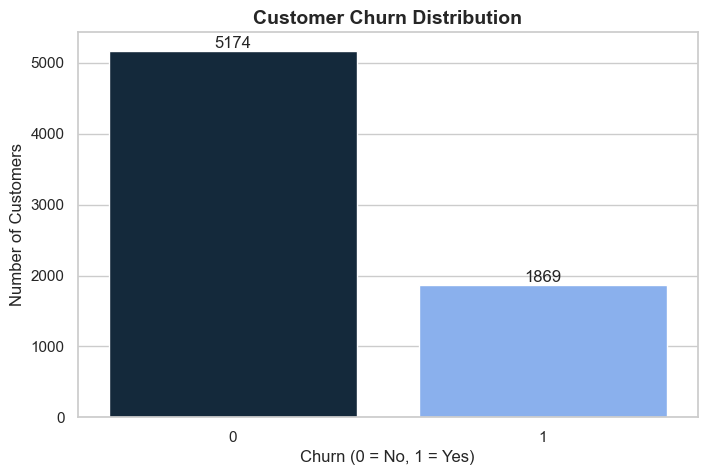

In [210]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()


ax = sns.countplot(x='Churn', hue='Churn', data=df,
                   palette=["#0D2A42", "#79ACFD"],
                   legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("Customer Churn Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()


## 📈 5. Churn Rate Analysis

This shows the percentage of customers who left the service.

In [211]:
churn_percent = df['Churn'].value_counts(normalize=True) * 100
churn_percent

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

**Insight:**
- Majority of customers (73.46%) stayed with the company  
- However, 26.54% churn rate is significant and represents a major revenue risk  

## 📊 6. Churn Analysis by Contract Type

We investigate how contract type affects customer retention.

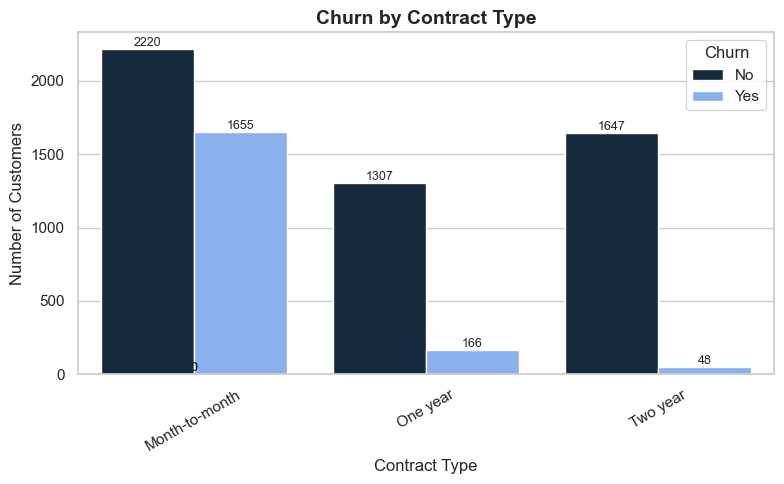

In [212]:
ax = sns.countplot(x='Contract', hue='Churn', data=df,
                   palette=["#0D2A42", "#79ACFD"])

plt.title("Churn by Contract Type", fontsize=14, fontweight='bold')
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

# ✨ Add value labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.legend(title="Churn", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

**Insight:** Customers on month-to-month contracts tend to churn more compared to long-term contracts.

## 🤖 7. Machine Learning Model (Logistic Regression)

We build a Logistic Regression model to predict customer churn. The dataset is scaled and split into training and testing sets to ensure model performance is reliable.

## 📊 8. Model Evaluation

We evaluate the model using accuracy, classification report, and confusion matrix.

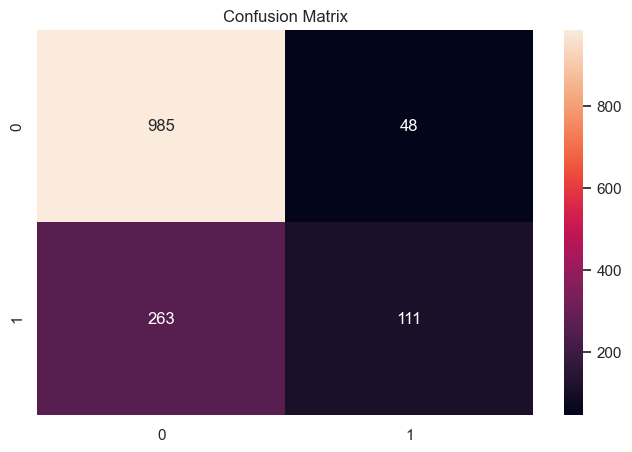

In [213]:
df_encoded.isnull().sum()
df_encoded = df_encoded.dropna()
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


# 📊 Scale the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# 📌 Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


# 🔮 Make predictions
y_pred = model.predict(X_test_scaled)


# 📊 Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
accuracy


# 📄 Full report
classification_report(y_test, y_pred)


sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## 🔍 9. Key Factors Influencing Churn

We identify which features have the strongest impact on customer churn.

In [214]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
7052,InternetService_Fiber optic,0.565021
7070,PaymentMethod_Electronic check,0.425319
0,SeniorCitizen,0.251415
7068,PaperlessBilling_Yes,0.250602
2,MonthlyCharges,0.246554
2456,customerID_3512-IZIKN,0.188629
6097,customerID_8631-NBHFZ,0.186738
2378,customerID_3400-ESFUW,0.185694
411,customerID_0607-DAAHE,0.185549
4484,customerID_6323-AYBRX,0.184974


Positive values indicate higher likelihood of churn, while negative values indicate customer retention factors.

## 📊 10. Top Factors Driving Customer Churn

This visualization highlights the most important variables influencing customer behavior.

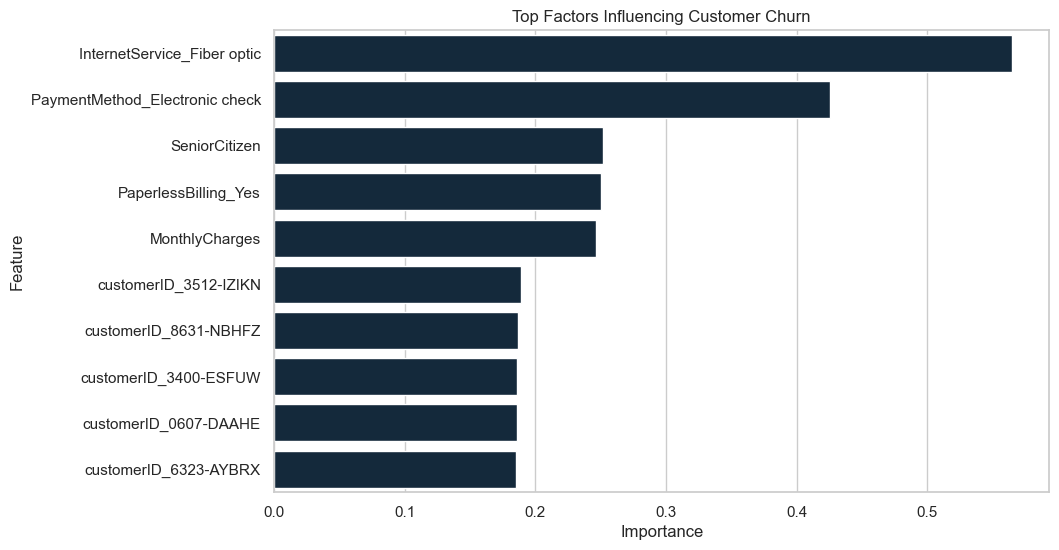

In [215]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance.head(10),
    color="#0D2A42"
)
plt.title("Top Factors Influencing Customer Churn")
plt.show()


## 🌲 11. Model Improvement (Random Forest)

We compare Logistic Regression with Random Forest to improve prediction performance.

In [216]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

accuracy_score(y_test, rf_pred)

0.7860696517412935

Random Forest is used to explore whether a more complex model improves prediction accuracy.
**Insight:** The model achieved approximately 79% accuracy on unseen data, indicating good predictive capability.

## 💡 Key Business Insights

From the analysis, the following patterns were observed:

- Month-to-month contracts have the highest churn rate  
- Higher monthly charges increase likelihood of churn  
- Long-term contracts improve customer retention  

## 🚀 Conclusion

This project demonstrates a full machine learning pipeline from data cleaning to model building and business insight generation.

It highlights how data science can be used to solve real-world business problems such as customer retention and revenue protection.

## 🔥 What I Learned

- Real-world data is messy and requires preprocessing  
- Machine learning is not just modeling but problem-solving  
- Business understanding is just as important as coding  

## 🚀 Open to Opportunities
I am actively seeking opportunities in Data Analysis / Data Science where I can apply data-driven solutions to real-world business problems.